In [1]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../FRB_cosmo/FRB_cosmo/interpolation')

## Import packages
from config import *
from support import *
from cosmo_support import *

import pickle
import os
from datetime import datetime

import emcee
from multiprocess import Pool, cpu_count

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# initial parameters
Hubble0 = 70
e_mu0 = 150
sigma_host0 = 0.5

# MCMC parameters
N_WALKERS = 16
HEATING = 10
N_STEPS = 800

# checkpoint
RESUME = False
CKP_INTERVAL = 50
SAVE_FILE = './DM_ext_checkpoint/simulation_data.pkl'
MCMC_FILE = './DM_ext_checkpoint/mcmc_checkpoint.pkl'

DATA_PATH = '../FRB_cosmo/interpolation/095_C0mean.npz'
interpolations = np.load(f'../Realistic_sources/quantile_linear_interpolations.npz')

N_EVENTS = 20
REDSHIFT_METHOD = 'rates'  # choose from 'rates', 'uniform', 'gaussian', 'lognormal' and 'powerlaw'

########################################
### Load standard parameters for pdf ###
########################################

S=0.133
EXP_MU=182.937
SIGMA_HOST=0.605
HOF=2.813

In [3]:
a=f_variance_delta(S=S, z=1.0)

print(a, np.sqrt(a))

0.08229342204584739 0.28686830087314874


In [4]:
print(HUBBLE* OMEGA_BARYONS*0.84)

2.7831805679999997


In [5]:
###################################
### Load interpolations for pdf ###
###################################

def _load_and_create_interpolators():
    load_arrays = np.load(DATA_PATH)
    Sigmas = load_arrays['a']
    Errors = load_arrays['d']
    C0s = load_arrays['c'] 
    As = load_arrays['b']
    
    sigma_error_inter = interpolate.interp1d(Errors, Sigmas, kind=1, bounds_error=False,fill_value='extrapolate')
    C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1, bounds_error=False,fill_value='extrapolate')
    A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1, bounds_error=False,fill_value='extrapolate')
    
    return Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter

Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = _load_and_create_interpolators()

z_array=np.linspace(0.2, 4.0, 1000)

# p_selection = redshift_distribution(z_array=z_array, H0=HUBBLE, Omega_m=OMEGA_MATTER, w, method=REDSHIFT_METHOD)
# p_selection = normalise(p_selection, z_array)

def initialize_globals():
    """Initialize global variables for worker processes"""
    global sigma_error_inter, C0_sigma_inter, A_sigma_inter
    global z_array
    
    if sigma_error_inter is None:
        Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = _load_and_create_interpolators()
        z_array = np.linspace(0.2, 4.0, 1000)

In [14]:
DM_th=DM_diff_HOf(z=z_val, HOf=HOF, Om=OMEGA_MATTER, w=W_LAMBDA)
print(0.25*DM_th, 1000+2.0*DM_th)

450.76011143413217 4606.080891473057


In [15]:
N=500

DM_obs = np.zeros(N)
sigma_obs = np.zeros(N)
DM_obs_fast = np.zeros(N)
sigma_obs_fast = np.zeros(N)

DM_diff = np.zeros(N)
sigma_diff = np.zeros(N)

z_val=0.4

for idx in range(N):

    DM_obs[idx], sigma_obs[idx] = \
        DM_ext_sampling(z=z_val, 
                        S=S, HOF=HOF, SIGMA_HOST=SIGMA_HOST, EXP_MU=EXP_MU,
                        sigma_error_inter=sigma_error_inter,
                        C0_sigma_inter=C0_sigma_inter,
                        A_sigma_inter=A_sigma_inter,
                        Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1, int_N=1000
                        )
        
    DM_obs_fast[idx], sigma_obs_fast[idx] = \
        DM_ext_sampling_fast(z=z_val, 
                        S=S, HOF=HOF, SIGMA_HOST=SIGMA_HOST, EXP_MU=EXP_MU,
                        sigma_error_inter=sigma_error_inter,
                        C0_sigma_inter=C0_sigma_inter,
                        A_sigma_inter=A_sigma_inter,
                        Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1, int_N=1000
                        )
        
    DM_diff[idx], sigma_diff[idx] = \
        DM_diff_sampling(z=z_val, # redshift
                    sigma_error_inter=sigma_error_inter,
                    C0_sigma_inter=C0_sigma_inter,
                    A_sigma_inter=A_sigma_inter,
                    S=S, HOF=None,
                     H0=HUBBLE, f_diff=0.84, f_diff_alpha=0, 
                     Om=OMEGA_MATTER, w=W_LAMBDA,
                     N_draws=1, int_N=1000,
                     mode='standard',
                     Error_factor = 1.0
                     )

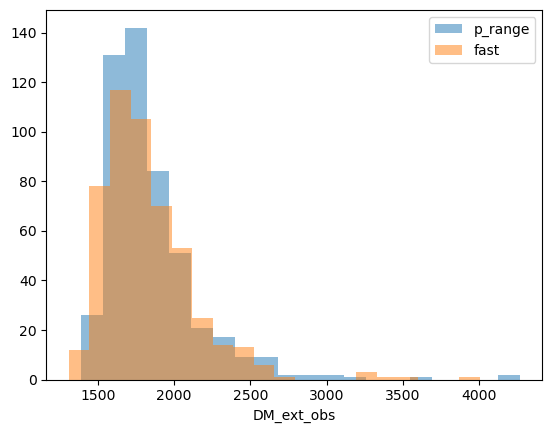

In [7]:
plt.hist(DM_obs, bins=20, label='p_range', alpha=0.5)
plt.hist(DM_obs_fast, bins=20, label='fast', alpha=0.5)
plt.xlabel('DM_ext_obs')
plt.legend()

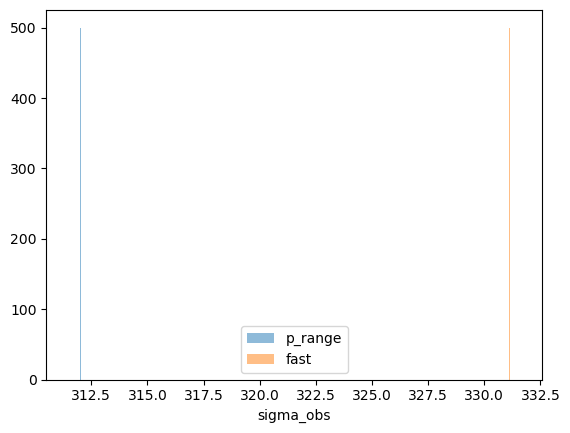

In [8]:
plt.hist(sigma_obs, bins=20, label='p_range', alpha=0.5)
plt.hist(sigma_obs_fast, bins=20, label='fast', alpha=0.5)
plt.xlabel('sigma_obs')
plt.legend()

In [ ]:
DM_th=dispersion_measure(z=z_val, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, alpha=0, f_IGM_0 = 0.84)

error=f_variance_delta(S=S, z=z_val, Om=OMEGA_MATTER, w=W_LAMBDA)
s_DM_obs = error*DM_th
    
sigma_diff=sigma_error_inter(error)
C0=C0_sigma_inter(sigma_diff)
A=A_sigma_inter(sigma_diff)

print(0.25*DM_th, 500+2.0*DM_th)
dm_range=np.linspace(600, 2000, 500)
    
p_range=[
    pdf_DM_cosmo(Delta=dm/DM_th, C_0=C0, A=A, sigma=sigma_diff, alpha=3, beta=3)/DM_th
    for dm in dm_range]
    
p_range=normalise(p_range)

445.9817927383545 4067.854341906836


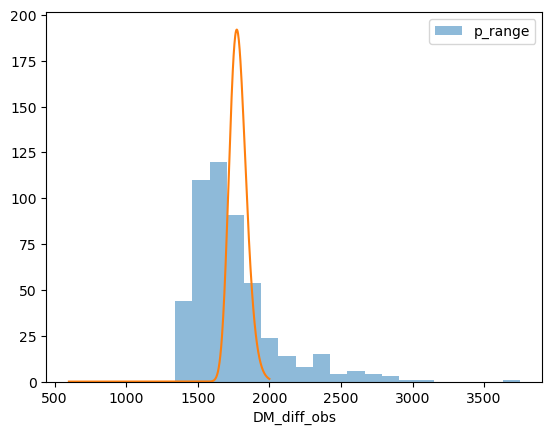

In [10]:
plt.hist(DM_diff, bins=20, label='p_range', alpha=0.5)
plt.plot(dm_range, p_range * N * 20)
plt.xlabel('DM_diff_obs')
plt.legend()

TypeError: len() of unsized object

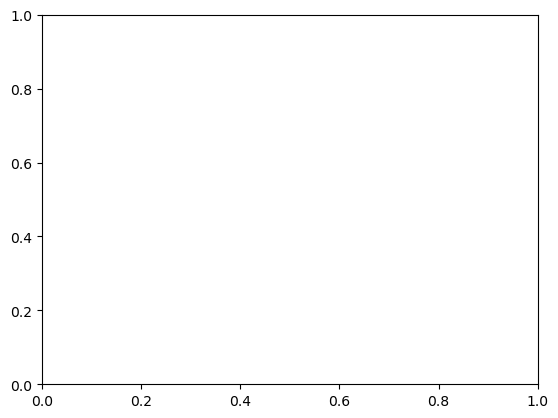

In [12]:
plt.hist(sigma_diff, bins=10, label='p_range', alpha=0.5)
plt.xlabel('sigma_obs')
plt.legend()